# Manual exploration of the datasets created by gpt5.2 and gemini

In [ ]:
from datasets import load_dataset,concatenate_datasets

ds1 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_openaigpt5.2_pk_1_t_0.7_v1.58",split="tikz")
ds2 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_googlegemini3propreview_pk_1_t_0.7_v1.58",split="tikz")
ds = concatenate_datasets([ds1,ds2])
df =ds.to_pandas()


In [11]:
any(metric==100 for metric in df["TemplateMetric"][0][0])

True

In [30]:
import numpy as np
df = df[df["TemplateMetric"].apply(
    lambda metrics: any(len(metric) > 0 and metric[0] != 100 for metric in metrics)
)]
i=  0


In [31]:
from IPython.display import HTML, display
import base64

def display_images_row(*img_jsons, max_height=300, margin=10):
    imgs = []
    for img in img_jsons:
        if img is None:
            continue
        b64 = base64.b64encode(img["bytes"]).decode("utf-8")
        imgs.append(
            f"<img src='data:image/png;base64,{b64}' "
            f"style='max-height:{max_height}px; margin-right:{margin}px;'>"
        )
    html = "<div style='display:flex; align-items:center;'>" + "".join(imgs) + "</div>"
    display(HTML(html))



Change the color of the dog to gray



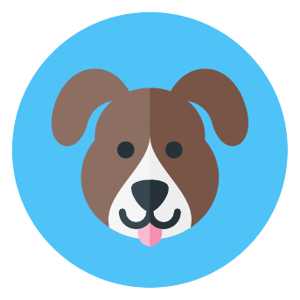
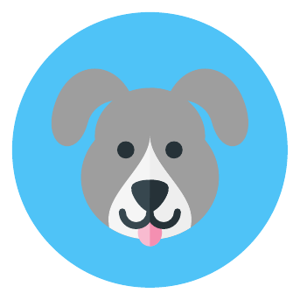
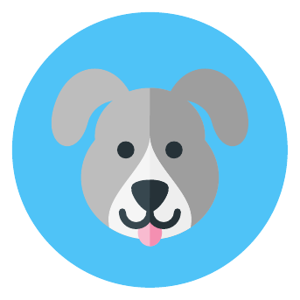

In [ ]:
i+=1
row = df.iloc[i]
print(row["instruction"])
display_images_row(
    row["image_input"],
    row["image_solution"][0],
    row["images_result"][0],
)
#TODO open and write to file the code template and code made by the llm